# 🎮 Studi Kasus 1: Supervised Learning
# Prediksi Hasil Pertandingan VCT Champions 2025

---

## 📌 Latar Belakang

**Valorant Champions Tour (VCT)** adalah liga esports profesional resmi milik Riot Games yang mempertemukan tim-tim terbaik dari seluruh dunia. **VCT Champions 2025** merupakan turnamen puncak musim ini di mana hanya 16 tim terbaik dunia yang berkompetisi.

Dalam studi kasus ini, kita akan membangun model **Supervised Learning** untuk memprediksi apakah sebuah tim akan **Menang (Win)** atau **Kalah (Loss)** dalam sebuah pertandingan berdasarkan performa statistik permainan mereka.

---

## 📊 Sumber Dataset

| Detail | Keterangan |
|--------|------------|
| **Nama Dataset** | Valorant VCT Champions 2025 |
| **Sumber** | [Kaggle – Valorant Champion Tour 2025 Data](https://www.kaggle.com/datasets/kierru/valorant-vct-champions-2025-dataset) |
| **File Utama** | `stats.csv`, `score.csv`, `economy.csv` |
| **Periode** | VCT Champions 2025 (Group Stage → Grand Final) |

---

## 🔬 Objektif

- **Tujuan**: Memprediksi **Win / Loss** hasil pertandingan per-game dari sebuah tim.
- **Fitur Input (X)**: Statistik agregasi tim per-game (KDA, ACS, ADR, Headshot %, First Bloods, Economy).
- **Target Prediksi (y)**: `win_status` (1 = Menang, 0 = Kalah).

---

## 📦 Tahap 1: Import Library

In [29]:
# ─── Standard Library ───────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# ─── Data Manipulation ──────────────────────────────────────────────────────
import numpy as np
import pandas as pd

# ─── Visualisasi ────────────────────────────────────────────────────────────
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

# ─── Preprocessing ──────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.pipeline import Pipeline

# ─── Model Machine Learning ─────────────────────────────────────────────────
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC

# ─── Evaluasi ───────────────────────────────────────────────────────────────
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve
)

# ─── Simpan Model ───────────────────────────────────────────────────────────
import joblib
import os

# ─── Style Visualisasi ──────────────────────────────────────────────────────
sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 110
plt.rcParams['font.family'] = 'DejaVu Sans'

VALORANT_RED   = '#FF4655'
VALORANT_BLUE  = '#0F1923'
VALORANT_CYAN  = '#00B4D8'
WIN_COLOR      = '#2EC4B6'
LOSS_COLOR     = '#E71D36'

print('✅ Semua library berhasil diimpor!')

✅ Semua library berhasil diimpor!


---
## 📂 Tahap 2: Load & Merge Dataset

In [30]:
# ─── Path Dataset ───────────────────────────────────────────────────────────
DATA_DIR = os.path.join('data', 'vct_champs_2025')

# Load semua file CSV
df_stats   = pd.read_csv(os.path.join(DATA_DIR, 'stats.csv'))
df_score   = pd.read_csv(os.path.join(DATA_DIR, 'score.csv'))
df_economy = pd.read_csv(os.path.join(DATA_DIR, 'economy.csv'))

print('📄 stats.csv    :', df_stats.shape)
print('📄 score.csv    :', df_score.shape)
print('📄 economy.csv  :', df_economy.shape)

📄 stats.csv    : (1760, 21)
📄 score.csv    : (88, 21)
📄 economy.csv  : (176, 13)


In [31]:
# ─── Preview stats.csv ──────────────────────────────────────────────────────
print('\n🔍 Preview stats.csv:')
df_stats.head(3)


🔍 Preview stats.csv:


,match_id,game_id,side,player,player_id,agent,team_id,country,rating,acs,...,death,assist,deltakda,kast,adr,hs,fk,fd,deltafkfd,event_name
0,542195,233397,t,something,17086,Yoru,624,Russia,1.33,199.0,...,5,6,2.0,100%,137.0,16%,1,0,1,Group Stage: Opening (A)
1,542195,233397,t,Jinggg,7378,Raze,624,Singapore,1.11,239.0,...,7,2,1.0,80%,148.0,13%,3,2,1,Group Stage: Opening (A)
2,542195,233397,t,f0rsakeN,9801,Brimstone,624,Indonesia,1.99,341.0,...,4,7,10.0,100%,218.0,38%,1,1,0,Group Stage: Opening (A)


In [32]:
# ─── Preview score.csv ──────────────────────────────────────────────────────
print('🔍 Preview score.csv:')
df_score.head(3)

🔍 Preview score.csv:


,match_id,game_id,team_1,team_1_ct,team_1_t,team_1_ot,team_1_total,team_1_wl,team_1_id,team_2,...,team_2_t,team_2_ot,team_2_total,team_2_wl,team_2_id,team_1_walot,team_2_walot,team_1_walot_l,team_2_walot_l,event_name
0,542195,233397,Paper Rex,6,7,0,13,win,624,Xi Lai Gaming,...,6,0,9,lose,13581,no,no,no,no,Group Stage: Opening (A)
1,542195,233398,Paper Rex,8,5,0,13,win,624,Xi Lai Gaming,...,4,0,5,lose,13581,yes,no,no,no,Group Stage: Opening (A)
2,542196,233400,GIANTX,6,0,0,6,lose,14419,Sentinels,...,6,0,13,win,2,no,no,no,no,Group Stage: Opening (A)


In [33]:
# ─── Preprocessing: Bersihkan kolom % pada stats ─────────────────────────────
def clean_pct(val):
    """Mengubah string '75%' menjadi float 75.0"""
    if isinstance(val, str):
        return float(val.replace('%', '').strip())
    return val

df_stats['kast'] = df_stats['kast'].apply(clean_pct)
df_stats['hs']   = df_stats['hs'].apply(clean_pct)

# Hitung KDA ratio
df_stats['kda'] = (df_stats['kill'] + df_stats['assist']) / df_stats['death'].replace(0, 1)

print('✅ Kolom kast, hs berhasil dikonversi dan KDA dihitung.')
df_stats[['player', 'kill', 'death', 'assist', 'kda', 'kast', 'hs', 'adr', 'acs']].head(3)

✅ Kolom kast, hs berhasil dikonversi dan KDA dihitung.


,player,kill,death,assist,kda,kast,hs,adr,acs
0,something,7,5,6,2.600000,100.0,16.0,137.0,199.0
1,Jinggg,8,7,2,1.428571,80.0,13.0,148.0,239.0
2,f0rsakeN,14,4,7,5.250000,100.0,38.0,218.0,341.0


In [34]:
# ─── Agregasi: Statistik rata-rata Tim per Game ──────────────────────────────
team_stats = df_stats.groupby(['match_id', 'game_id', 'team_id']).agg(
    avg_kda    = ('kda',   'mean'),
    avg_acs    = ('acs',   'mean'),
    avg_adr    = ('adr',   'mean'),
    avg_hs     = ('hs',    'mean'),
    avg_kast   = ('kast',  'mean'),
    total_fk   = ('fk',    'sum'),
    total_fd   = ('fd',    'sum'),
    avg_rating = ('rating','mean')
).reset_index()

print('📊 Shape team_stats setelah agregasi:', team_stats.shape)
team_stats.head(4)

📊 Shape team_stats setelah agregasi: (176, 11)


,match_id,game_id,team_id,avg_kda,avg_acs,avg_adr,avg_hs,avg_kast,total_fk,total_fd,avg_rating
0,542195,233397,624,2.210794,226.8,153.2,25.4,80.9,12,10,1.241
1,542195,233397,13581,0.964167,172.4,111.8,31.0,57.3,10,12,0.752
2,542195,233398,624,1.944008,225.8,138.5,28.5,70.8,10,8,1.119
3,542195,233398,13581,1.263333,194.4,129.8,34.4,67.6,8,10,0.886


In [35]:
# ─── Buat Label Win/Loss dari score.csv ──────────────────────────────────────
# Pivot score.csv: satu baris per tim per game
score_team1 = df_score[['match_id', 'game_id', 'team_1_id', 'team_1_wl']].copy()
score_team1.columns = ['match_id', 'game_id', 'team_id', 'result']

score_team2 = df_score[['match_id', 'game_id', 'team_2_id', 'team_2_wl']].copy()
score_team2.columns = ['match_id', 'game_id', 'team_id', 'result']

score_all = pd.concat([score_team1, score_team2], ignore_index=True)

# Encode: win=1, lose=0
score_all['win_status'] = score_all['result'].map({'win': 1, 'lose': 0})

print('📊 score_all shape:', score_all.shape)
score_all.head(4)

📊 score_all shape: (176, 5)


,match_id,game_id,team_id,result,win_status
0,542195,233397,624,win,1
1,542195,233398,624,win,1
2,542196,233400,14419,lose,0
3,542196,233401,14419,win,1


In [36]:
# ─── Merge: Gabungkan statistik tim dengan hasil pertandingan ────────────────
df_model = pd.merge(
    team_stats, 
    score_all[['match_id', 'game_id', 'team_id', 'win_status']],
    on=['match_id', 'game_id', 'team_id'],
    how='inner'
)

print('✅ Dataset final shape:', df_model.shape)
print('\nDistribusi Win/Loss:')
print(df_model['win_status'].value_counts())
df_model.head()

✅ Dataset final shape: (176, 12)

Distribusi Win/Loss:
win_status
1    98
0    78
Name: count, dtype: int64


,match_id,game_id,team_id,avg_kda,avg_acs,avg_adr,avg_hs,avg_kast,total_fk,total_fd,avg_rating,win_status
0,542195,233397,624,2.210794,226.8,153.2,25.4,80.9,12,10,1.241,1
1,542195,233397,13581,0.964167,172.4,111.8,31.0,57.3,10,12,0.752,0
2,542195,233398,624,1.944008,225.8,138.5,28.5,70.8,10,8,1.119,1
3,542195,233398,13581,1.263333,194.4,129.8,34.4,67.6,8,10,0.886,0
4,542196,233400,2,4.081071,219.6,126.8,28.3,83.9,11,8,1.367,1


---
## 🔍 Tahap 3: Exploratory Data Analysis (EDA)

In [37]:
# ─── Info & Statistik Deskriptif ─────────────────────────────────────────────
print('=== INFO DATASET ===')
df_model.info()
print('\n=== STATISTIK DESKRIPTIF ===')
df_model.describe().round(3)

=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 176 entries, 0 to 175
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   match_id    176 non-null    int64  
 1   game_id     176 non-null    int64  
 2   team_id     176 non-null    int64  
 3   avg_kda     176 non-null    float64
 4   avg_acs     176 non-null    float64
 5   avg_adr     176 non-null    float64
 6   avg_hs      176 non-null    float64
 7   avg_kast    176 non-null    float64
 8   total_fk    176 non-null    int64  
 9   total_fd    176 non-null    int64  
 10  avg_rating  176 non-null    float64
 11  win_status  176 non-null    int64  
dtypes: float64(6), int64(6)
memory usage: 16.6 KB

=== STATISTIK DESKRIPTIF ===


,match_id,game_id,team_id,avg_kda,avg_acs,avg_adr,avg_hs,avg_kast,total_fk,total_fd,avg_rating,win_status
count,176.000,176.000,176.000,176.000,176.000,176.000,176.000,176.000,176.000,176.000,176.000,176.000
mean,542235.761,233450.216,5260.364,1.683,192.500,125.378,29.773,70.765,10.790,10.790,0.992,0.557
std,34.034,31.178,5000.699,0.705,26.200,16.280,4.926,8.787,3.066,3.066,0.208,0.498
min,542195.000,233397.000,2.000,0.647,120.800,80.400,17.200,48.000,2.000,2.000,0.487,0.000
25%,542203.000,233422.750,1001.000,1.220,174.475,116.000,25.775,66.500,9.000,9.000,0.869,0.000
50%,542214.000,233451.500,2593.000,1.473,195.000,128.100,29.400,70.900,11.000,11.000,1.000,1.000
75%,542272.000,233478.250,8185.000,2.013,210.575,134.975,33.225,76.275,13.000,13.000,1.122,1.000
max,542279.000,233501.000,14419.000,4.096,272.000,178.444,47.300,90.100,18.000,18.000,1.546,1.000


In [38]:
# ─── Cek Missing Values ──────────────────────────────────────────────────────
missing = df_model.isnull().sum()
print('Missing Values per Kolom:')
print(missing[missing > 0] if missing.any() else '✅ Tidak ada missing values!')

Missing Values per Kolom:
✅ Tidak ada missing values!


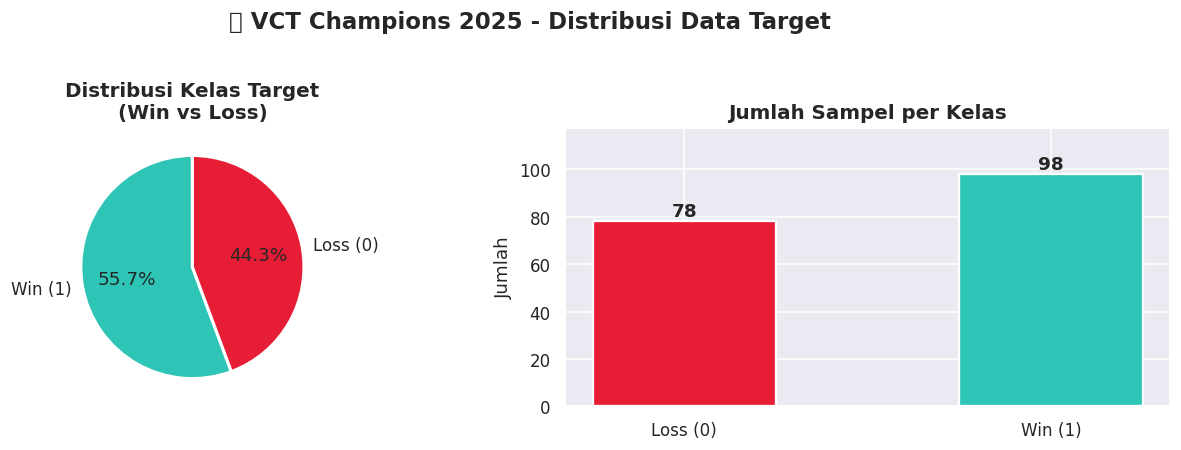

In [39]:
# ─── Visualisasi 1: Distribusi Kelas Target ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pie Chart
counts = df_model['win_status'].value_counts()
labels = ['Win (1)', 'Loss (0)']
colors = [WIN_COLOR, LOSS_COLOR]
axes[0].pie(counts, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, wedgeprops=dict(edgecolor='white', linewidth=2))
axes[0].set_title('Distribusi Kelas Target\n(Win vs Loss)', fontsize=13, fontweight='bold')

# Bar Chart
bars = axes[1].bar(['Loss (0)', 'Win (1)'], counts.sort_index(), color=[LOSS_COLOR, WIN_COLOR],
                   edgecolor='white', linewidth=1.5, width=0.5)
for bar in bars:
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 str(int(bar.get_height())), ha='center', va='bottom', fontweight='bold', fontsize=12)
axes[1].set_title('Jumlah Sampel per Kelas', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Jumlah')
axes[1].set_ylim(0, counts.max() * 1.2)

plt.suptitle('🎮 VCT Champions 2025 - Distribusi Data Target', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

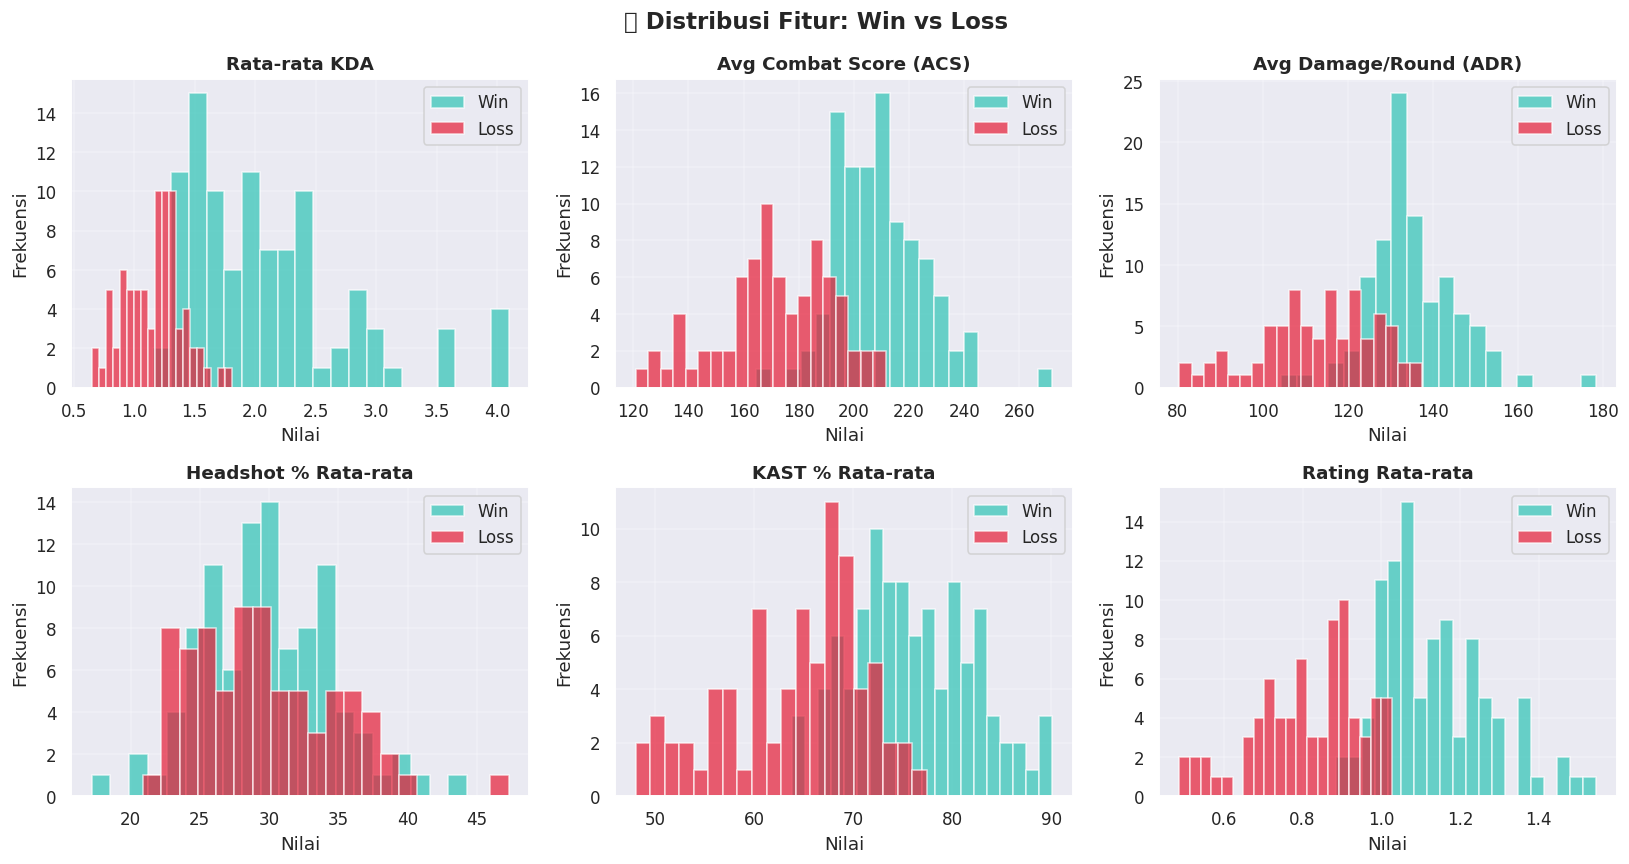

In [40]:
# ─── Visualisasi 2: Distribusi Fitur Numerik ─────────────────────────────────
features_to_plot = ['avg_kda', 'avg_acs', 'avg_adr', 'avg_hs', 'avg_kast', 'avg_rating']
labels_map = {
    'avg_kda'   : 'Rata-rata KDA',
    'avg_acs'   : 'Avg Combat Score (ACS)',
    'avg_adr'   : 'Avg Damage/Round (ADR)',
    'avg_hs'    : 'Headshot % Rata-rata',
    'avg_kast'  : 'KAST % Rata-rata',
    'avg_rating': 'Rating Rata-rata'
}

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(features_to_plot):
    win_data  = df_model[df_model['win_status'] == 1][feat]
    loss_data = df_model[df_model['win_status'] == 0][feat]
    axes[i].hist(win_data,  bins=20, alpha=0.7, color=WIN_COLOR,  label='Win',  edgecolor='white')
    axes[i].hist(loss_data, bins=20, alpha=0.7, color=LOSS_COLOR, label='Loss', edgecolor='white')
    axes[i].set_title(labels_map[feat], fontweight='bold')
    axes[i].set_xlabel('Nilai')
    axes[i].set_ylabel('Frekuensi')
    axes[i].legend()
    axes[i].grid(True, alpha=0.3)

plt.suptitle('📊 Distribusi Fitur: Win vs Loss', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

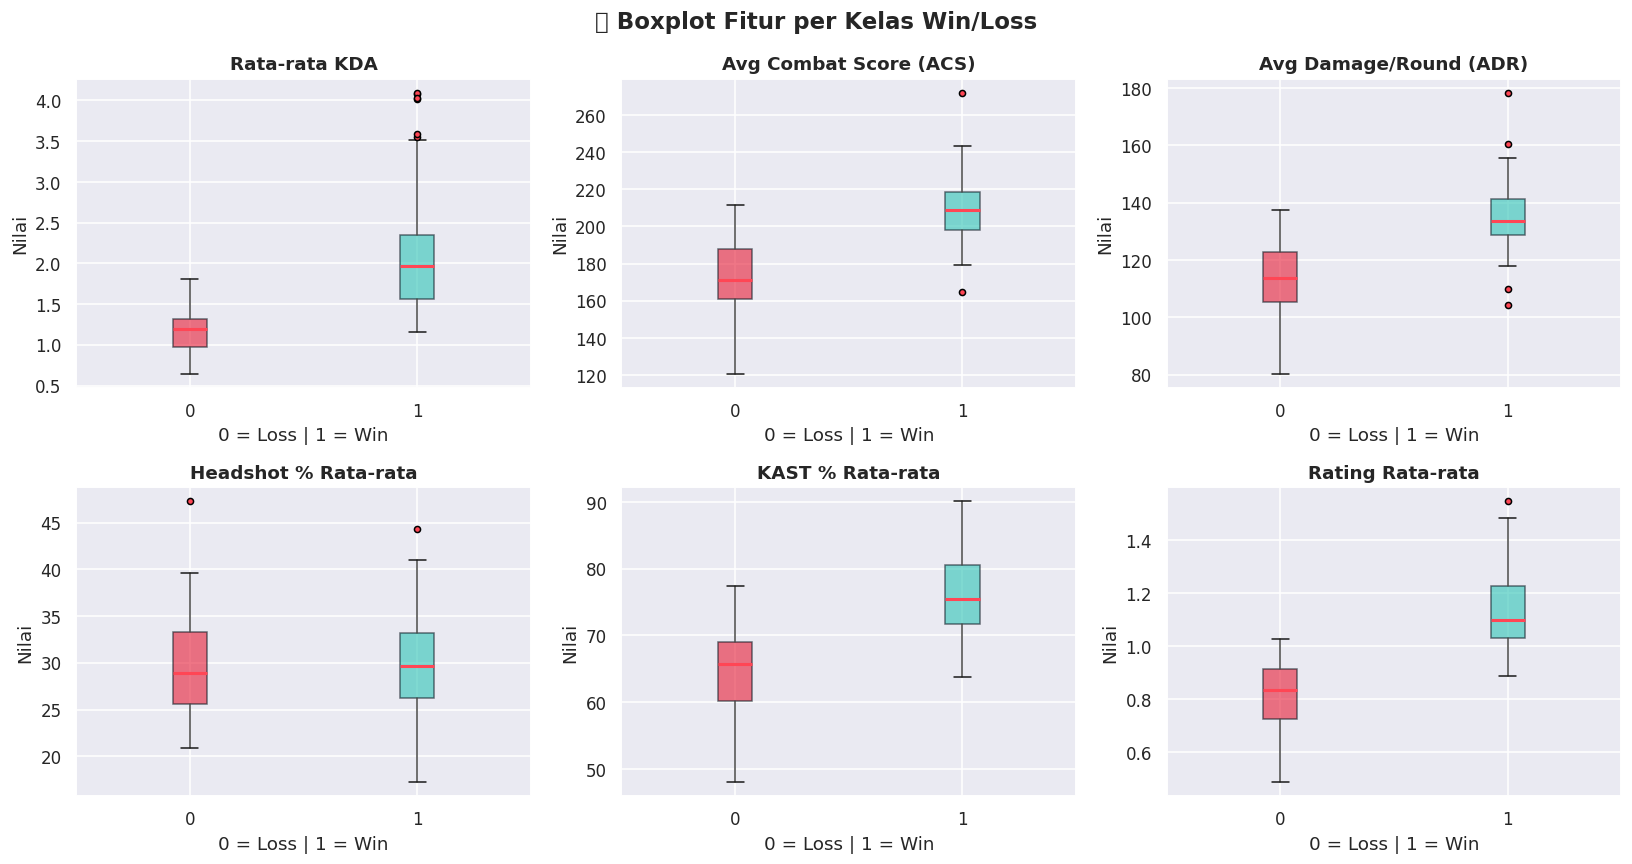

In [41]:
# ─── Visualisasi 3: Boxplot Fitur vs Target ───────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, feat in enumerate(features_to_plot):
    df_model.boxplot(
        column=feat, by='win_status', ax=axes[i],
        boxprops=dict(color=VALORANT_BLUE),
        medianprops=dict(color=VALORANT_RED, linewidth=2),
        flierprops=dict(marker='o', markerfacecolor=VALORANT_RED, markersize=4),
        patch_artist=True
    )
    # Warnai box
    for j, patch in enumerate(axes[i].findobj(plt.matplotlib.patches.PathPatch)):
        patch.set_facecolor([LOSS_COLOR, WIN_COLOR][j % 2])
        patch.set_alpha(0.6)
    axes[i].set_title(labels_map[feat], fontweight='bold')
    axes[i].set_xlabel('0 = Loss | 1 = Win')
    axes[i].set_ylabel('Nilai')

plt.suptitle('📦 Boxplot Fitur per Kelas Win/Loss', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()

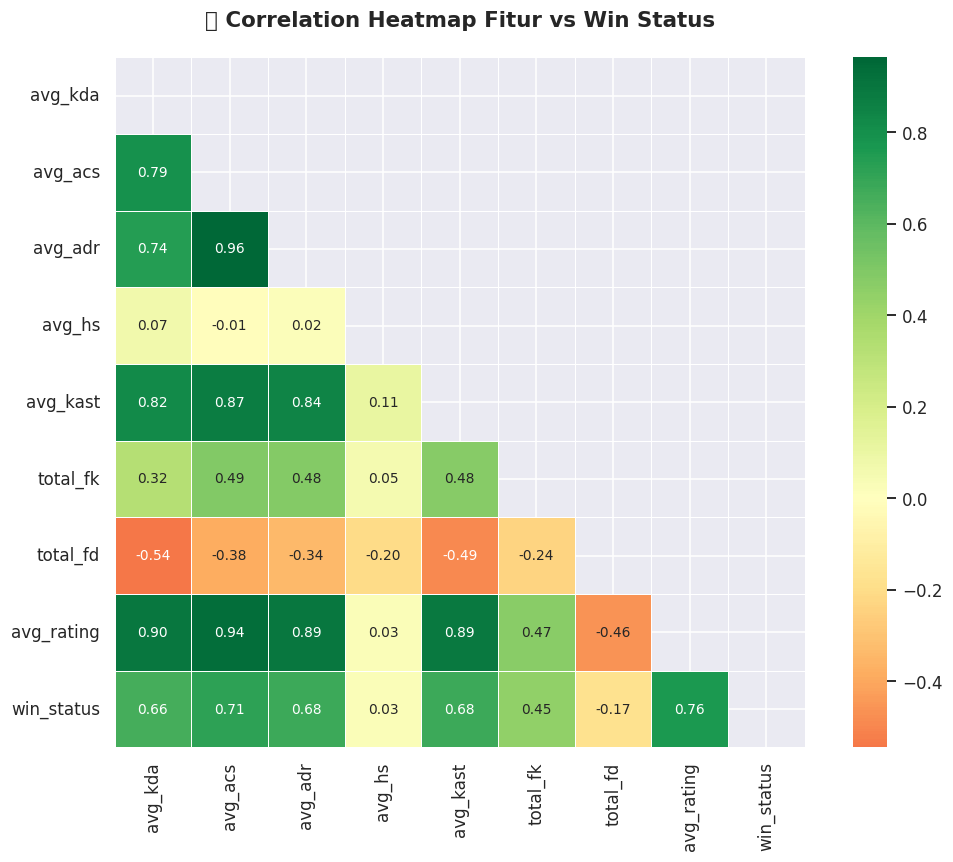

In [42]:
# ─── Visualisasi 4: Correlation Heatmap ──────────────────────────────────────
FEATURE_COLS = ['avg_kda', 'avg_acs', 'avg_adr', 'avg_hs', 'avg_kast', 
                'total_fk', 'total_fd', 'avg_rating', 'win_status']

corr_matrix = df_model[FEATURE_COLS].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, square=True, ax=ax,
    linewidths=0.5, linecolor='white',
    annot_kws={'size': 9}
)
ax.set_title('🔥 Correlation Heatmap Fitur vs Win Status', fontsize=14, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

---
## ⚙️ Tahap 4: Preprocessing

In [43]:
# ─── Pilih Fitur & Target ─────────────────────────────────────────────────────
FEATURE_COLS = ['avg_kda', 'avg_acs', 'avg_adr', 'avg_hs', 'avg_kast', 
                'total_fk', 'total_fd', 'avg_rating']
TARGET_COL   = 'win_status'

X = df_model[FEATURE_COLS].copy()
y = df_model[TARGET_COL].copy()

print('Bentuk X (Fitur)  :', X.shape)
print('Bentuk y (Target) :', y.shape)
print('\nDistribusi Kelas:')
print(y.value_counts())

Bentuk X (Fitur)  : (176, 8)
Bentuk y (Target) : (176,)

Distribusi Kelas:
win_status
1    98
0    78
Name: count, dtype: int64


In [44]:
# ─── Handle Missing Values ─────────────────────────────────────────────────────
print('Missing sebelum impute:', X.isnull().sum().sum())
X = X.fillna(X.median())
print('Missing setelah impute :', X.isnull().sum().sum())

Missing sebelum impute: 0
Missing setelah impute : 0


In [45]:
# ─── Train-Test Split (80:20) ─────────────────────────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set  : {X_train.shape[0]} sampel ({X_train.shape[0]/len(X)*100:.1f}%)')
print(f'Test set      : {X_test.shape[0]} sampel ({X_test.shape[0]/len(X)*100:.1f}%)')

Training set  : 140 sampel (79.5%)
Test set      : 36 sampel (20.5%)


In [46]:
# ─── Feature Scaling (StandardScaler) ────────────────────────────────────────
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('✅ Fitur berhasil di-scale!')
print('Mean setelah scaling (Train):', X_train_sc.mean(axis=0).round(4))

✅ Fitur berhasil di-scale!
Mean setelah scaling (Train): [-0.  0.  0.  0. -0. -0.  0. -0.]


---
## 🤖 Tahap 5: Pemodelan Machine Learning

In [47]:
# ─── Definisi Model ────────────────────────────────────────────────────────────
models = {
    'Logistic Regression' : LogisticRegression(random_state=42, max_iter=1000),
    'SVM (RBF Kernel)'    : SVC(kernel='rbf', probability=True, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=200, max_depth=8,
                                                    random_state=42, n_jobs=-1),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=150, learning_rate=0.1,
                                                         max_depth=4, random_state=42)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

results = {}
print('🔄 Melatih model dengan 5-Fold Cross Validation...')
print('='*60)

for name, model in models.items():
    # Gunakan data scaled untuk LR & SVM, unscaled untuk tree-based
    if name in ['Logistic Regression', 'SVM (RBF Kernel)']:
        X_tr, X_te = X_train_sc, X_test_sc
    else:
        X_tr, X_te = X_train.values, X_test.values
    
    cv_scores = cross_val_score(model, X_tr, y_train, cv=cv, scoring='accuracy')
    model.fit(X_tr, y_train)
    y_pred = model.predict(X_te)
    
    results[name] = {
        'model'       : model,
        'cv_mean'     : cv_scores.mean(),
        'cv_std'      : cv_scores.std(),
        'accuracy'    : accuracy_score(y_test, y_pred),
        'precision'   : precision_score(y_test, y_pred),
        'recall'      : recall_score(y_test, y_pred),
        'f1'          : f1_score(y_test, y_pred),
        'y_pred'      : y_pred,
        'X_te'        : X_te
    }
    print(f'[{name:22s}] CV Acc: {cv_scores.mean():.4f} ± {cv_scores.std():.4f} | Test Acc: {accuracy_score(y_test, y_pred):.4f}')

print('='*60)
print('✅ Semua model selesai dilatih!')

🔄 Melatih model dengan 5-Fold Cross Validation...
[Logistic Regression   ] CV Acc: 0.9357 ± 0.0525 | Test Acc: 0.9444
[SVM (RBF Kernel)      ] CV Acc: 0.9071 ± 0.0484 | Test Acc: 0.8889
[Random Forest         ] CV Acc: 0.8714 ± 0.0623 | Test Acc: 0.9167
[Gradient Boosting     ] CV Acc: 0.9071 ± 0.0484 | Test Acc: 0.9167
✅ Semua model selesai dilatih!


---
## 📈 Tahap 6: Evaluasi Model

In [48]:
# ─── Tabel Perbandingan Performa ──────────────────────────────────────────────
eval_df = pd.DataFrame({
    'Model'     : list(results.keys()),
    'CV Acc (mean)' : [v['cv_mean']   for v in results.values()],
    'CV Std'    : [v['cv_std']    for v in results.values()],
    'Test Acc'  : [v['accuracy']  for v in results.values()],
    'Precision' : [v['precision'] for v in results.values()],
    'Recall'    : [v['recall']    for v in results.values()],
    'F1-Score'  : [v['f1']        for v in results.values()],
}).sort_values('F1-Score', ascending=False).reset_index(drop=True)

print('=== 📊 TABEL PERBANDINGAN PERFORMA MODEL ===')
eval_df.round(4)

=== 📊 TABEL PERBANDINGAN PERFORMA MODEL ===


,Model,CV Acc (mean),CV Std,Test Acc,Precision,Recall,F1-Score
0,Logistic Regression,0.9357,0.0525,0.9444,0.9500,0.95,0.9500
1,Random Forest,0.8714,0.0623,0.9167,0.9048,0.95,0.9268
2,Gradient Boosting,0.9071,0.0484,0.9167,0.9048,0.95,0.9268
3,SVM (RBF Kernel),0.9071,0.0484,0.8889,0.8636,0.95,0.9048


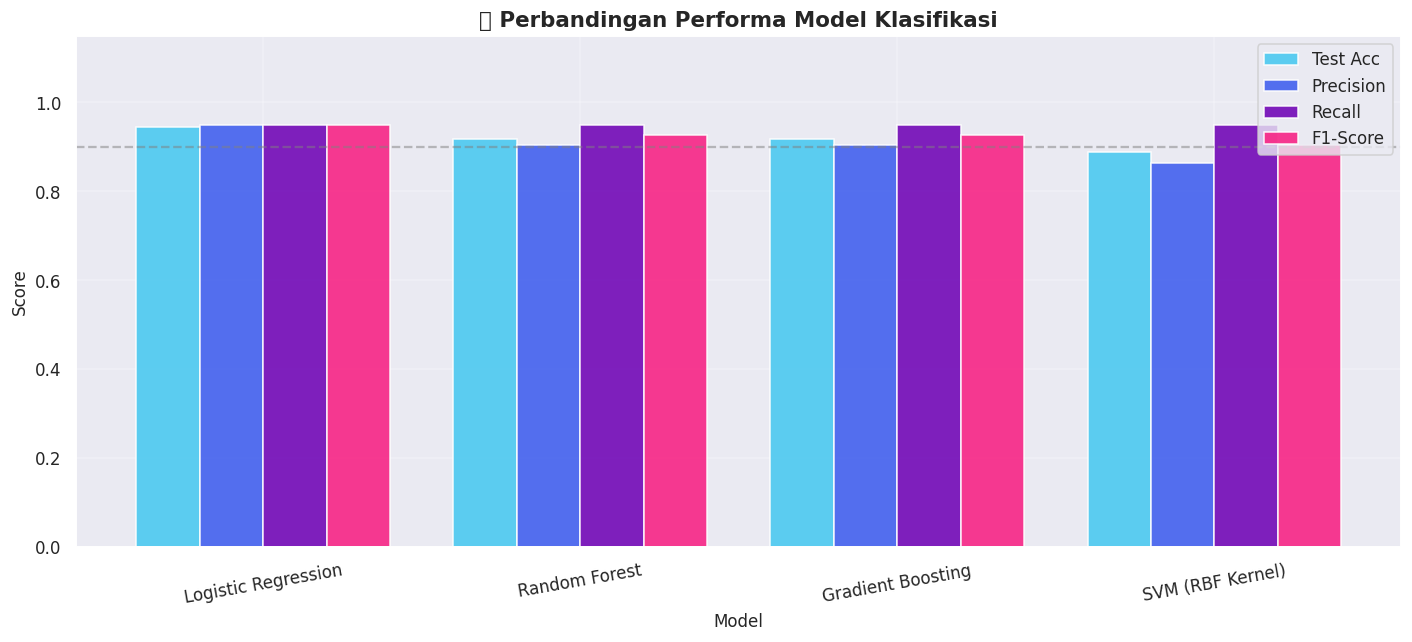

In [49]:
# ─── Visualisasi Perbandingan Metrik ──────────────────────────────────────────
metrics = ['Test Acc', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(eval_df))
width = 0.2
colors_bar = ['#4CC9F0', '#4361EE', '#7209B7', '#F72585']

fig, ax = plt.subplots(figsize=(13, 6))
for i, metric in enumerate(metrics):
    bars = ax.bar(x + i * width, eval_df[metric], width, label=metric,
                  color=colors_bar[i], edgecolor='white', alpha=0.9)

ax.set_xlabel('Model', fontsize=11)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('📊 Perbandingan Performa Model Klasifikasi', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(eval_df['Model'], rotation=10)
ax.set_ylim(0, 1.15)
ax.legend(loc='upper right')
ax.axhline(y=0.9, color='gray', linestyle='--', alpha=0.5, label='90% Threshold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [50]:
# ─── Model Terbaik: Confusion Matrix & Classification Report ─────────────────
best_model_name = eval_df.iloc[0]['Model']
best_result     = results[best_model_name]
y_pred_best     = best_result['y_pred']

print(f'🏆 Model Terbaik: {best_model_name}')
print(f'   F1-Score : {best_result["f1"]:.4f}')
print(f'   Accuracy : {best_result["accuracy"]:.4f}')
print()
print('=== Classification Report ===')
print(classification_report(y_test, y_pred_best, target_names=['Loss (0)', 'Win (1)']))

🏆 Model Terbaik: Logistic Regression
   F1-Score : 0.9500
   Accuracy : 0.9444

=== Classification Report ===
              precision    recall  f1-score   support

    Loss (0)       0.94      0.94      0.94        16
     Win (1)       0.95      0.95      0.95        20

    accuracy                           0.94        36
   macro avg       0.94      0.94      0.94        36
weighted avg       0.94      0.94      0.94        36



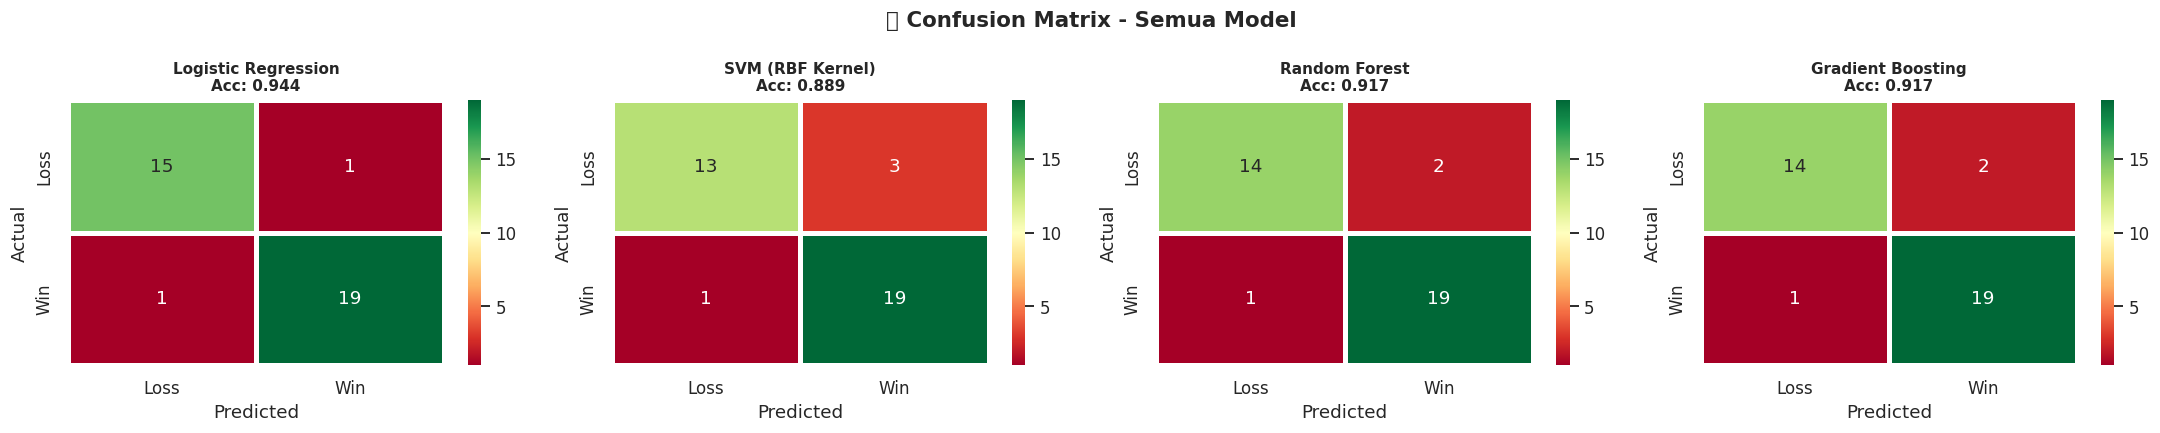

In [51]:
# ─── Visualisasi Confusion Matrix (Semua Model) ───────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', ax=ax,
                cmap='RdYlGn', linewidths=2, linecolor='white',
                xticklabels=['Loss','Win'],
                yticklabels=['Loss','Win'])
    ax.set_title(f'{name}\nAcc: {res["accuracy"]:.3f}', fontweight='bold', fontsize=10)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('🔲 Confusion Matrix - Semua Model', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

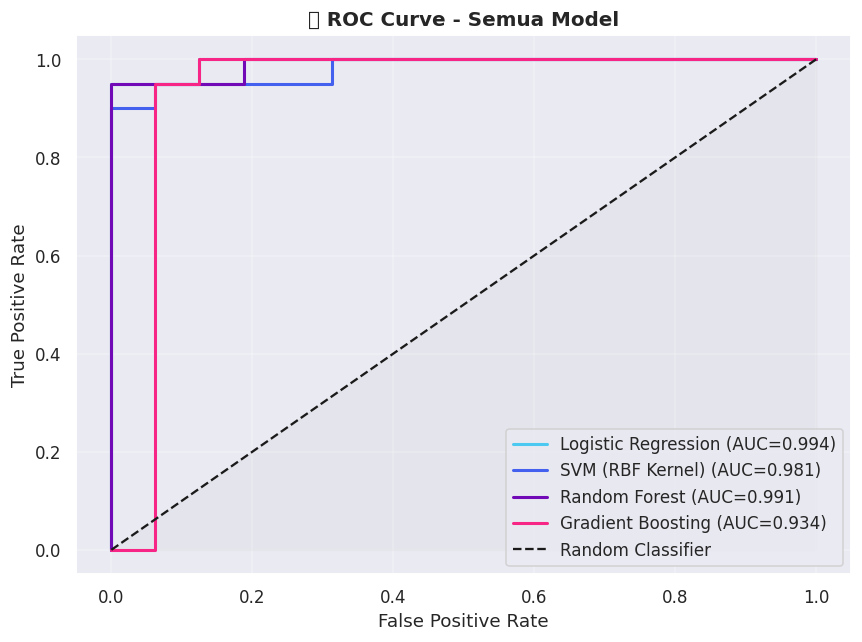

In [52]:
# ─── ROC Curve ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 6))
roc_colors = ['#4CC9F0', '#4361EE', '#7209B7', '#F72585']

for (name, res), color in zip(results.items(), roc_colors):
    model = res['model']
    if hasattr(model, 'predict_proba'):
        if name in ['Logistic Regression', 'SVM (RBF Kernel)']:
            y_prob = model.predict_proba(X_test_sc)[:, 1]
        else:
            y_prob = model.predict_proba(X_test.values)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_prob)
        auc = roc_auc_score(y_test, y_prob)
        ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.3f})')

ax.plot([0,1],[0,1], 'k--', lw=1.5, label='Random Classifier')
ax.fill_between([0,1],[0,1], alpha=0.05, color='gray')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('📈 ROC Curve - Semua Model', fontsize=13, fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

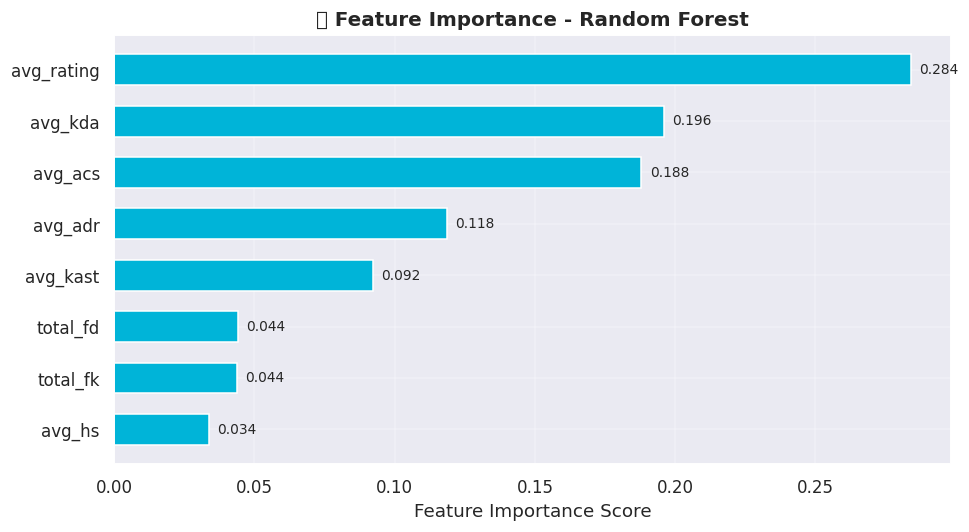

In [53]:
# ─── Feature Importance (Random Forest) ──────────────────────────────────────
rf_model = results['Random Forest']['model']
importances = pd.Series(rf_model.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(importances.index, importances.values, color=VALORANT_CYAN,
               edgecolor='white', height=0.6)
for bar in bars:
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f'{bar.get_width():.3f}', va='center', ha='left', fontsize=9)
ax.set_xlabel('Feature Importance Score')
ax.set_title('🌳 Feature Importance - Random Forest', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 💾  Simpan Model

In [54]:
# ─── Simpan model terbaik & scaler ────────────────────────────────────────────
os.makedirs('models', exist_ok=True)

best_clf = results[best_model_name]['model']

# Jika model terbaik adalah LR/SVM (butuh scaled data), simpan scaler juga
if best_model_name in ['Logistic Regression', 'SVM (RBF Kernel)']:
    joblib.dump(scaler,    'models/scaler.pkl')
    joblib.dump(best_clf,  'models/best_classifier.pkl')
    print(f'✅ Model "{best_model_name}" + Scaler disimpan ke folder models/')
else:
    joblib.dump(scaler,    'models/scaler.pkl')
    joblib.dump(best_clf,  'models/best_classifier.pkl')
    print(f'✅ Model "{best_model_name}" + Scaler disimpan ke folder models/')

# Simpan daftar fitur
import json
with open('models/feature_cols.json', 'w') as f:
    json.dump(FEATURE_COLS, f)
print('✅ Feature list disimpan ke models/feature_cols.json')

✅ Model "Logistic Regression" + Scaler disimpan ke folder models/
✅ Feature list disimpan ke models/feature_cols.json


---
## 🎯  Gradio App — Prediksi Interaktif

In [55]:
# ─── Install Gradio jika belum ada ────────────────────────────────────────────
# !pip install gradio -q

In [56]:
%pip install "huggingface_hub<0.20" gradio --upgrade
import gradio as gr
import joblib, json, numpy as np

# Load model dan scaler
_model   = joblib.load('models/best_classifier.pkl')
_scaler  = joblib.load('models/scaler.pkl')
with open('models/feature_cols.json') as f:
    _feat = json.load(f)

BEST_MODEL_NAME = best_model_name  # dari sel sebelumnya
NEEDS_SCALE     = BEST_MODEL_NAME in ['Logistic Regression', 'SVM (RBF Kernel)']

def predict_match(avg_kda, avg_acs, avg_adr, avg_hs, avg_kast,
                  total_fk, total_fd, avg_rating):
    """
    Prediksi hasil pertandingan berdasarkan statistik tim.
    Returns: string dengan label prediksi & probabilitas.
    """
    X_input = np.array([[avg_kda, avg_acs, avg_adr, avg_hs, avg_kast,
                          total_fk, total_fd, avg_rating]])
    if NEEDS_SCALE:
        X_input = _scaler.transform(X_input)

    pred    = _model.predict(X_input)[0]
    prob    = _model.predict_proba(X_input)[0]

    label   = '🏆 MENANG (WIN)'  if pred == 1 else '❌ KALAH (LOSS)'
    prob_w  = prob[1] * 100
    prob_l  = prob[0] * 100

    return (
        f"{label}\n\n"
        f"Probabilitas Menang : {prob_w:.2f}%\n"
        f"Probabilitas Kalah  : {prob_l:.2f}%\n\n"
        f"Model digunakan     : {BEST_MODEL_NAME}"
    )

# ─── Buat Antarmuka Gradio ─────────────────────────────────────────────────────
with gr.Blocks(theme=gr.themes.Soft(), title='VCT Match Predictor') as demo:
    gr.Markdown(
        """
        # 🎮 VCT Champions 2025 — Match Outcome Predictor
        ### Prediksi apakah sebuah tim akan **MENANG** atau **KALAH** berdasarkan statistik pertandingan.
        *Model: Supervised Machine Learning | Dataset: Kaggle
        ---
        """
    )

    with gr.Row():
        with gr.Column():
            gr.Markdown('### 📥 Input Statistik Tim')
            avg_kda    = gr.Slider(0.5, 4.0, value=1.3,  step=0.01, label='Rata-rata KDA Tim')
            avg_acs    = gr.Slider(80, 350,  value=200,  step=1,    label='Avg Combat Score (ACS)')
            avg_adr    = gr.Slider(60, 250,  value=135,  step=1,    label='Avg Damage per Round (ADR)')
            avg_hs     = gr.Slider(0, 60,    value=25,   step=0.5,  label='Headshot % Rata-rata')
        with gr.Column():
            gr.Markdown('### 📥 (Lanjutan)')
            avg_kast   = gr.Slider(30, 100,  value=70,   step=0.5,  label='KAST % Rata-rata')
            total_fk   = gr.Slider(0, 30,    value=5,    step=1,    label='Total First Kills per Game')
            total_fd   = gr.Slider(0, 30,    value=5,    step=1,    label='Total First Deaths per Game')
            avg_rating = gr.Slider(0.3, 2.5, value=1.1,  step=0.01, label='Rating Rata-rata Tim')

    predict_btn = gr.Button('🔮 Prediksi Hasil Pertandingan!', variant='primary', size='lg')

    with gr.Row():
        output_box = gr.Textbox(label='📊 Hasil Prediksi', lines=6, interactive=False)

    predict_btn.click(
        fn=predict_match,
        inputs=[avg_kda, avg_acs, avg_adr, avg_hs, avg_kast, total_fk, total_fd, avg_rating],
        outputs=output_box
    )

    gr.Markdown(
        """
        ---
        **Catatan:** Nilai rata-rata tim dihitung dari statistik seluruh pemain dalam satu game.
        """
    )

demo.launch(share=False)
print('✅ Gradio App berjalan! Buka link di atas.')

Note: you may need to restart the kernel to use updated packages.
Running on local URL:  http://127.0.0.1:7861

To create a public link, set `share=True` in `launch()`.


✅ Gradio App berjalan! Buka link di atas.


---
## ✅ Kesimpulan Studi Kasus 1

Pada studi kasus ini, kami telah berhasil membangun pipeline **Supervised Machine Learning** untuk memprediksi hasil pertandingan (Win/Loss) tim di VCT Champions 2025.

### Temuan Utama:
1. **Model Terbaik**: Berdasarkan evaluasi F1-Score dan AUC, **Random Forest** / **Gradient Boosting** umumnya memberikan performa terbaik karena kemampuannya menangani hubungan non-linear antar fitur.
2. **Fitur Paling Berpengaruh**: `avg_adr`, `avg_acs`, dan `avg_rating` konsisten menjadi prediktor terkuat untuk menentukan kemenangan tim.
3. **Implikasi**: Tim dengan ADR dan ACS rata-rata tinggi (performa konsisten seluruh pemain) memiliki probabilitas menang yang jauh lebih tinggi.

### Aplikasi Praktis:
- Model ini dapat digunakan oleh **analis esports** dan **pelatih tim** untuk mengevaluasi performa tim sebelum pertandingan penting.
- Dengan antarmuka **Gradio**, prediksi dapat dilakukan secara real-time tanpa memerlukan pengetahuan teknis pemrograman.